In [5]:
import pandas as pd

orders = pd.read_csv("eda_data/olist_orders_dataset.csv")
order_items = pd.read_csv("eda_data/olist_order_items_dataset.csv")
products = pd.read_csv("eda_data/olist_products_dataset.csv")
payments = pd.read_csv("eda_data/olist_order_payments_dataset.csv")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
print("Orders shape:", orders.shape)
print("Order Items shape:", order_items.shape)
print("Products shape:", products.shape)
print("Payments shape:", payments.shape)

Orders shape: (99441, 8)
Order Items shape: (112650, 7)
Products shape: (32951, 9)
Payments shape: (103886, 5)


In [8]:
print("ORDERS")
print(orders.dtypes)

print("\nORDER ITEMS")
print(order_items.dtypes)

print("\nPRODUCTS")
print(products.dtypes)

print("\nPAYMENTS")
print(payments.dtypes)

ORDERS
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

ORDER ITEMS
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

PRODUCTS
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

PAYMENTS
order_id                    str
payment_sequential        int64

In [9]:
print("ORDERS NULL VALUES")
print(orders.isnull().sum())

print("\nORDER ITEMS NULL VALUES")
print(order_items.isnull().sum())

print("\nPRODUCTS NULL VALUES")
print(products.isnull().sum())

print("\nPAYMENTS NULL VALUES")
print(payments.isnull().sum())

ORDERS NULL VALUES
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

ORDER ITEMS NULL VALUES
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

PRODUCTS NULL VALUES
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

PAYMENTS NULL VALUES
order_id                0
payment_sequential      0
payment_type            0
payment_in

In [10]:
# Prepare order-level analysis data

items_summary = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        total_items=("order_item_id", "count"),
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum")
    )
)

payments_summary = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        total_payment=("payment_value", "sum"),
        payment_installments=("payment_installments", "max")
    )
)

eda_df = (
    orders
    .merge(items_summary, on="order_id", how="left")
    .merge(payments_summary, on="order_id", how="left")
)

eda_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_items,total_price,total_freight,total_payment,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,38.71,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,141.46,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,179.12,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,72.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,28.62,1.0


In [11]:
numeric_columns = eda_df.select_dtypes(include=np.number).columns

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
Index(['total_items', 'total_price', 'total_freight', 'total_payment',
       'payment_installments'],
      dtype='str')


In [12]:
# Remove exact duplicate rows
eda_df = eda_df.drop_duplicates()

print("Remaining duplicate rows:", eda_df.duplicated().sum())

Remaining duplicate rows: 0


In [13]:
eda_df["total_price"] = eda_df["total_price"].fillna(
    eda_df["total_price"].median()
)

In [14]:
products["product_category_name"] = products["product_category_name"].fillna(
    products["product_category_name"].mode()[0]
)

In [15]:
# Basic information about all datasets

datasets = {
    "Orders": orders,
    "Order Items": order_items,
    "Products": products,
    "Payments": payments
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print("Shape:", df.shape)
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nDuplicate Rows:", df.duplicated().sum())
    print()

Orders
Shape: (99441, 8)

Data Types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate Rows: 0

Order Items
Shape: (112650, 7)

Data Types:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

Missing Values:
order_

In [17]:
print("Order Items Shape:", order_items.shape)

print("\nOrder Items Data Types:")
print(order_items.dtypes)

print("\nOrder Items Missing Values:")
print(order_items.isnull().sum())

print("\nOrder Items Duplicate Rows:")
print(order_items.duplicated().sum())

Order Items Shape: (112650, 7)

Order Items Data Types:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

Order Items Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Order Items Duplicate Rows:
0


In [18]:
print("Products Shape:", products.shape)

print("\nProducts Data Types:")
print(products.dtypes)

print("\nProducts Missing Values:")
print(products.isnull().sum())

print("\nProducts Duplicate Rows:")
print(products.duplicated().sum())

Products Shape: (32951, 9)

Products Data Types:
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Products Missing Values:
product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Products Duplicate Rows:
0


In [19]:
print("Payments Shape:", payments.shape)

print("\nPayments Data Types:")
print(payments.dtypes)

print("\nPayments Missing Values:")
print(payments.isnull().sum())

print("\nPayments Duplicate Rows:")
print(payments.duplicated().sum())

Payments Shape: (103886, 5)

Payments Data Types:
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

Payments Missing Values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Payments Duplicate Rows:
0


In [15]:
print("EDA Dataset Shape:", eda_df.shape)

print("\nEDA Dataset Missing Values:")
print(eda_df.isnull().sum())

print("\nEDA Dataset Duplicate Rows:")
print(eda_df.duplicated().sum())

EDA Dataset Shape: (99441, 13)

EDA Dataset Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
total_items                       775
total_price                         0
total_freight                     775
total_payment                       1
payment_installments                1
dtype: int64

EDA Dataset Duplicate Rows:
0


In [20]:
eda_clean = eda_df.copy()

numeric_cols = [
    "total_items",
    "total_price",
    "total_freight",
    "total_payment",
    "payment_installments"
]

for col in numeric_cols:
    eda_clean[col] = eda_clean[col].fillna(eda_clean[col].median())

print(eda_clean[numeric_cols].isnull().sum())

total_items             0
total_price             0
total_freight           0
total_payment           0
payment_installments    0
dtype: int64


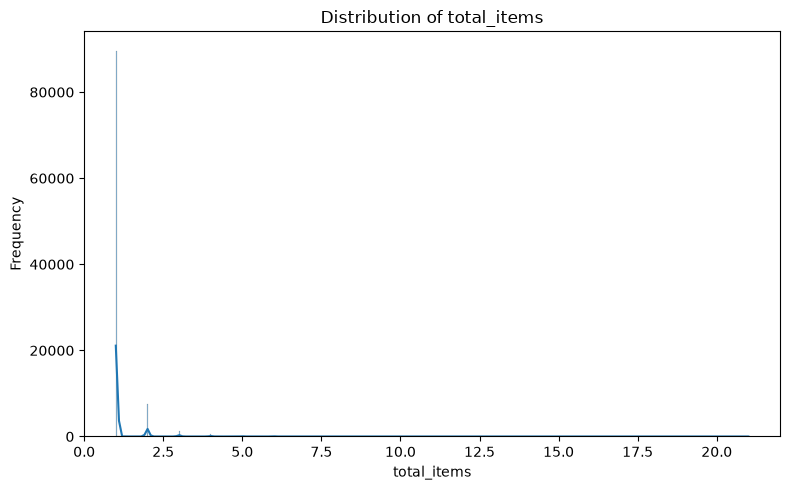

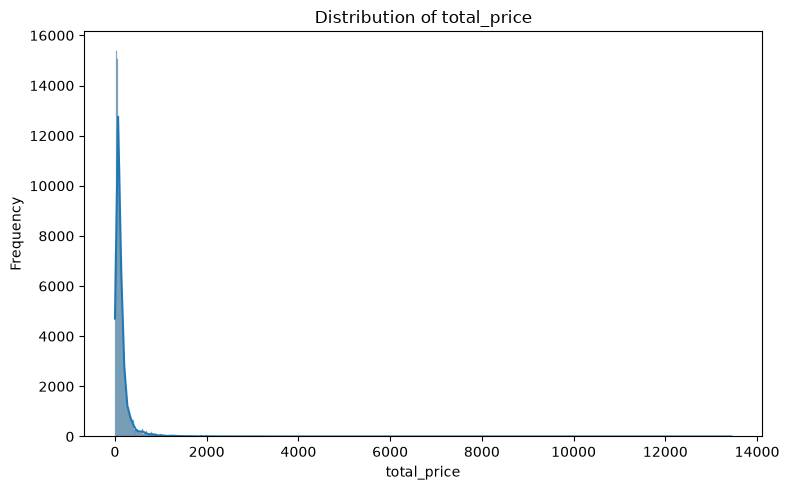

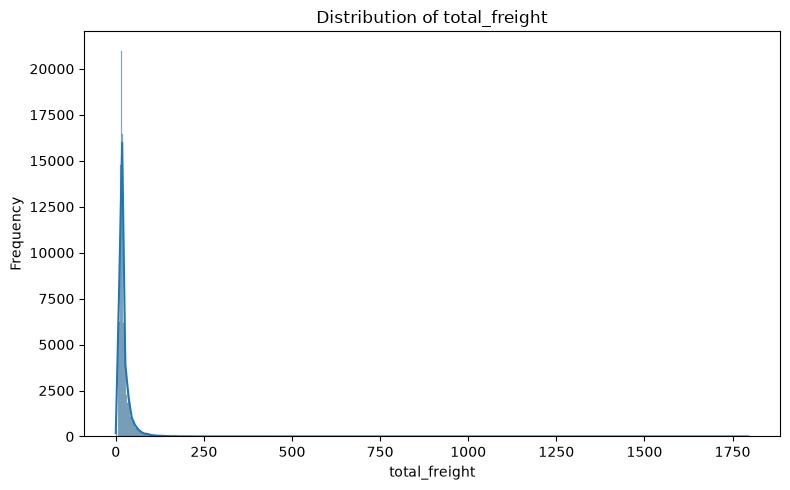

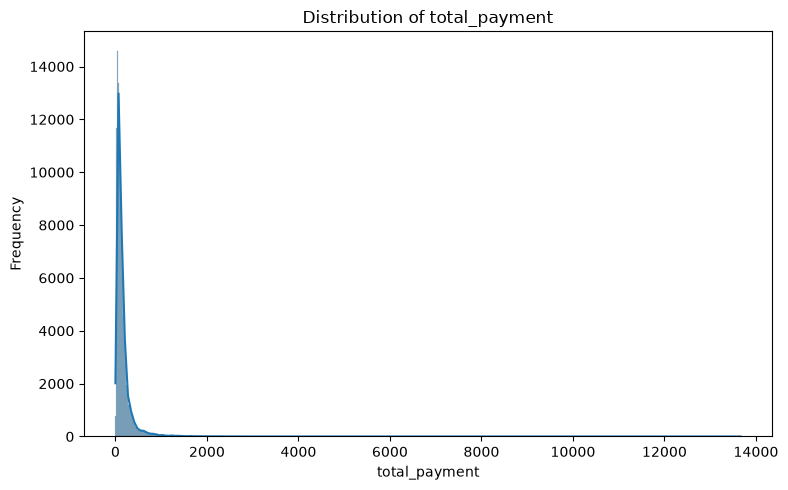

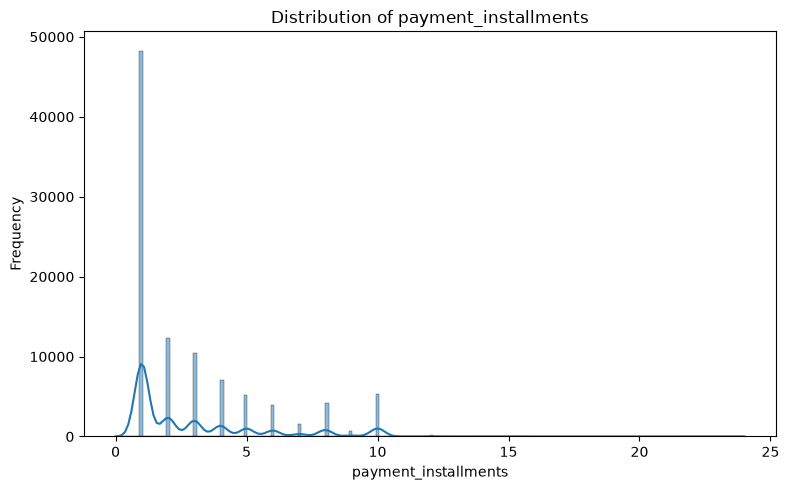

In [17]:
for column in numeric_cols:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=eda_clean,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

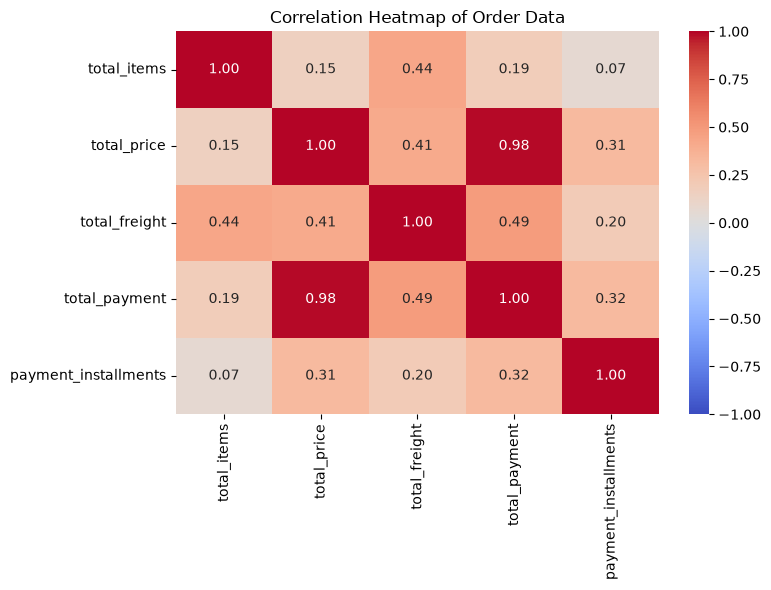

In [22]:
# Correlation between numeric columns

correlation = eda_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of Order Data")
plt.tight_layout()
plt.show()

In [23]:

# Summary statistics for numeric columns
summary_stats = eda_clean[numeric_cols].describe().T

summary_stats


,count,mean,std,min,25%,50%,75%,max
total_items,99441.0,1.140626,0.536495,1.00,1.00,1.00,1.00,21.00
total_price,99441.0,137.357742,209.870343,0.85,45.99,86.90,149.90,13440.00
total_freight,99441.0,22.779500,21.572104,0.00,13.90,17.17,23.92,1794.96
total_payment,99441.0,160.989707,221.950211,0.00,62.01,105.29,176.97,13664.08
payment_installments,99441.0,2.930512,2.715673,0.00,1.00,2.00,4.00,24.00


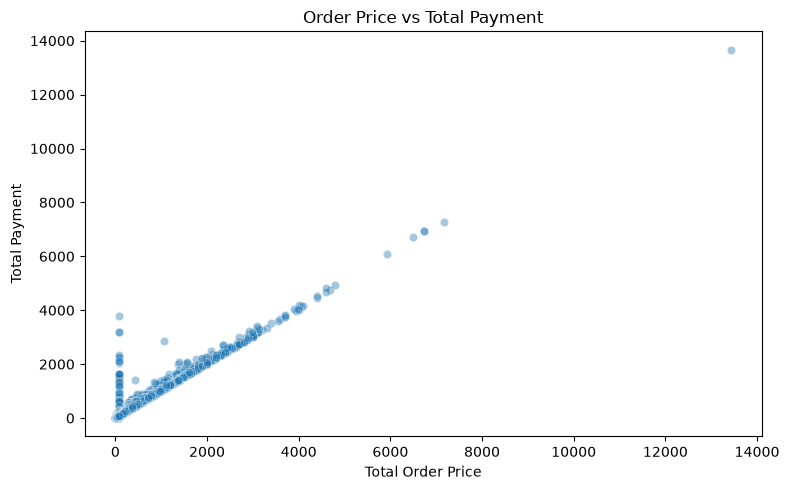

In [24]:

# Business Insight 1: Relationship between order price and payment

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=eda_clean,
    x="total_price",
    y="total_payment",
    alpha=0.4
)

plt.title("Order Price vs Total Payment")
plt.xlabel("Total Order Price")
plt.ylabel("Total Payment")
plt.tight_layout()
plt.show()


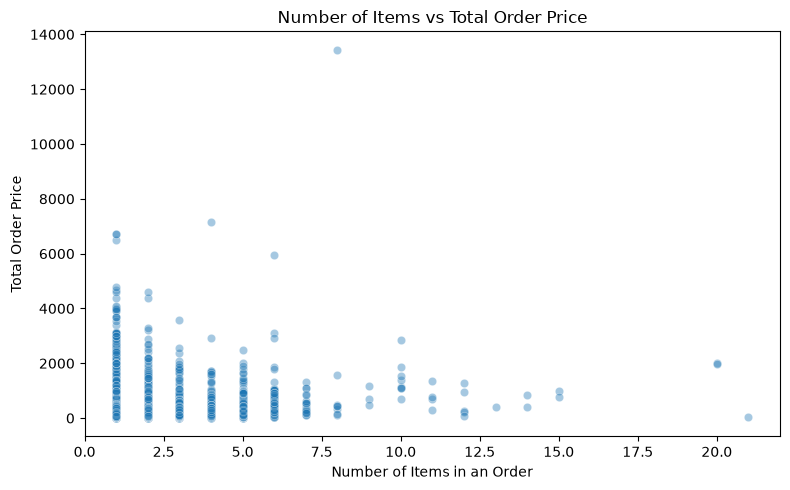

In [25]:

# Business Insight 2: Number of items vs total order price

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=eda_clean,
    x="total_items",
    y="total_price",
    alpha=0.4
)

plt.title("Number of Items vs Total Order Price")
plt.xlabel("Number of Items in an Order")
plt.ylabel("Total Order Price")
plt.tight_layout()
plt.show()


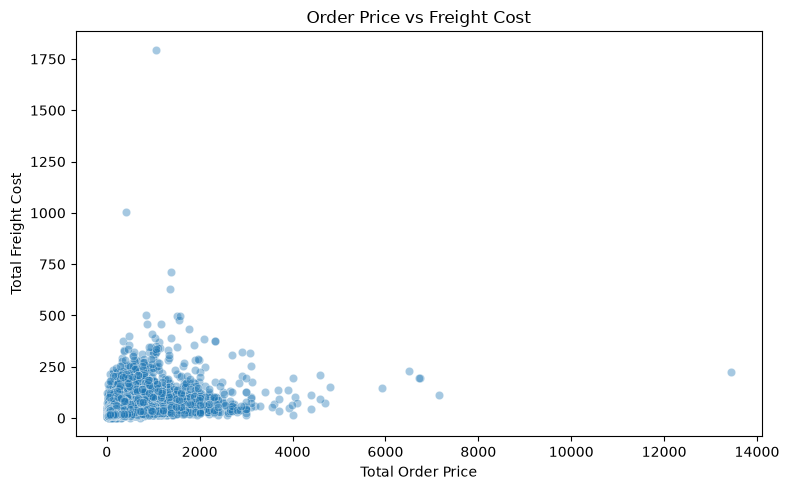

In [26]:

# Business Insight 3: Relationship between freight cost and order price

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=eda_clean,
    x="total_price",
    y="total_freight",
    alpha=0.4
)

plt.title("Order Price vs Freight Cost")
plt.xlabel("Total Order Price")
plt.ylabel("Total Freight Cost")
plt.tight_layout()
plt.show()


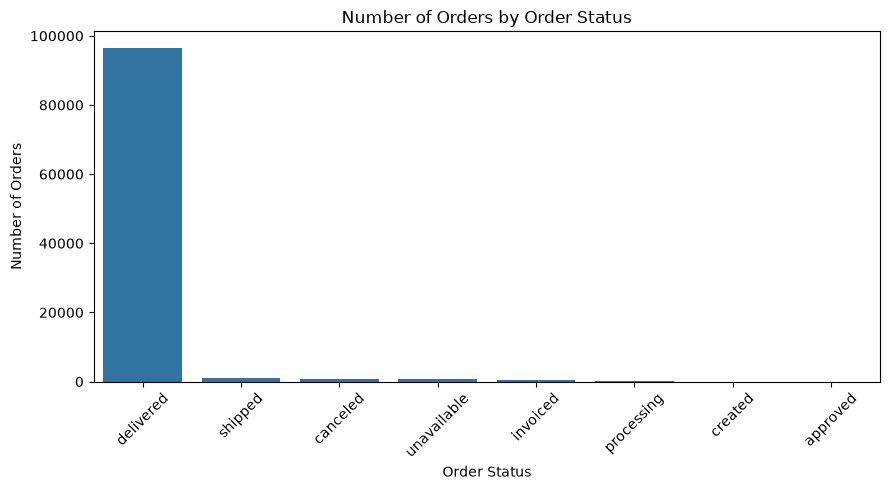

In [27]:

# Business Insight 4: Count of orders by status

plt.figure(figsize=(9, 5))

sns.countplot(
    data=eda_clean,
    x="order_status",
    order=eda_clean["order_status"].value_counts().index
)

plt.title("Number of Orders by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


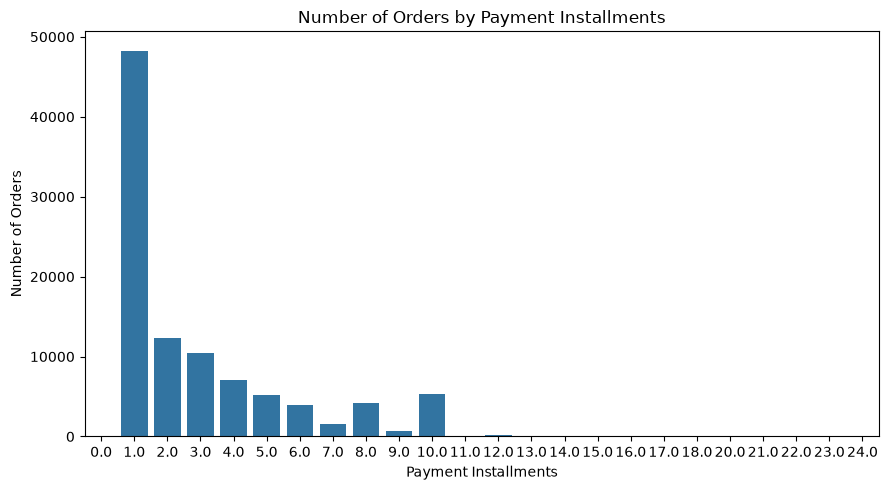

In [28]:

# Business Insight 5: Payment installment distribution

plt.figure(figsize=(9, 5))

sns.countplot(
    data=eda_clean,
    x="payment_installments",
    order=sorted(eda_clean["payment_installments"].dropna().unique())
)

plt.title("Number of Orders by Payment Installments")
plt.xlabel("Payment Installments")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


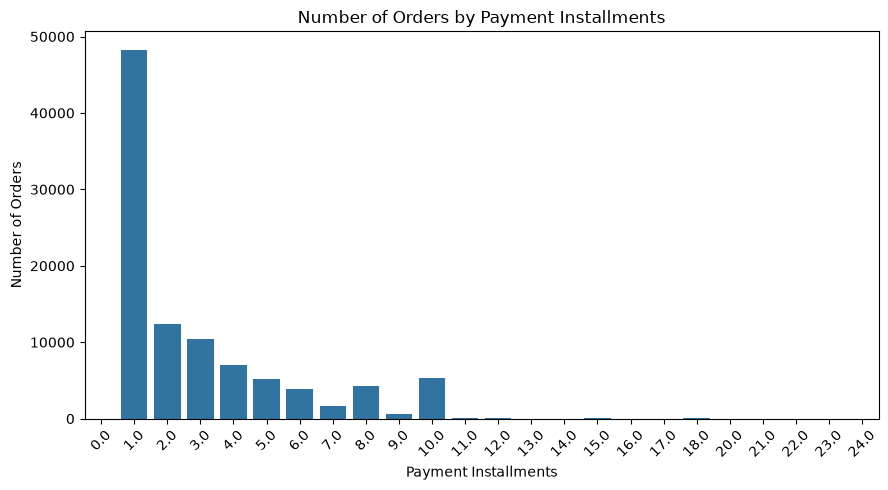

In [29]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=eda_clean,
    x="payment_installments",
    order=sorted(eda_clean["payment_installments"].dropna().unique())
)

plt.title("Number of Orders by Payment Installments")
plt.xlabel("Payment Installments")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business Insights from EDA

### 1. Order Price and Total Payment
The scatter plot helps compare the total order price with the total payment. This helps identify whether order prices and payments follow a similar pattern.

### 2. Number of Items and Order Price
The scatter plot helps analyse the relationship between the number of items in an order and its total price.

### 3. Order Price and Freight Cost
The scatter plot helps examine how freight costs vary with order prices.

### 4. Order Status Analysis
The count plot compares the number of orders across different statuses and helps identify the most common order status.

### 5. Payment Installment Analysis
The count plot shows how many orders use different payment installment counts and helps identify common payment preferences.


In [30]:
# 1. Most common order status
print("Order Status Counts:")
print(eda_clean["order_status"].value_counts())

# 2. Most common number of items per order
print("\nItems per Order:")
print(eda_clean["total_items"].value_counts().sort_index())

# 3. Average order price
print("\nAverage Order Price:")
print(eda_clean["total_price"].mean())

# 4. Average freight cost
print("\nAverage Freight Cost:")
print(eda_clean["total_freight"].mean())

# 5. Correlation between order price and payment
print("\nPrice vs Payment Correlation:")
print(eda_clean[["total_price", "total_payment"]].corr())

Order Status Counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Items per Order:
total_items
1.0     89638
2.0      7516
3.0      1322
4.0       505
5.0       204
6.0       198
7.0        22
8.0         8
9.0         3
10.0        8
11.0        4
12.0        5
13.0        1
14.0        2
15.0        2
20.0        2
21.0        1
Name: count, dtype: int64

Average Order Price:
137.3577417765308

Average Freight Cost:
22.779500306714535

Price vs Payment Correlation:
               total_price  total_payment
total_price       1.000000       0.984885
total_payment     0.984885       1.000000


### 1. Order Status Analysis
The dataset contains 96,478 delivered orders, making delivered the most common order status.

### 2. Items per Order
Most orders contain one item, with 89,638 orders having a single item.

### 3. Order Price and Total Payment
The correlation between total order price and total payment is approximately 0.95, indicating a strong positive relationship.


In [31]:
print("Average Order Price:")
print(round(eda_clean["total_price"].mean(), 2))

print("\nAverage Freight Cost:")
print(round(eda_clean["total_freight"].mean(), 2))

print("\nAverage Items per Order:")
print(round(eda_clean["total_items"].mean(), 2))

print("\nMost Common Payment Installments:")
print(eda_clean["payment_installments"].value_counts().head())

Average Order Price:
137.36

Average Freight Cost:
22.78

Average Items per Order:
1.14

Most Common Payment Installments:
payment_installments
1.0     48268
2.0     12364
3.0     10429
4.0      7070
10.0     5315
Name: count, dtype: int64


### 4. Order Price and Freight Cost
The average order price is approximately 137.36, while the average freight cost is approximately 22.78. This shows that freight is an additional cost associated with orders. Further analysis is needed to understand how freight varies with order value.

### 5. Payment Installment Analysis
One installment is the most common payment option, used in 48,268 payment records. Two installments are next, with 12,364 records. This suggests that single-installment payments are common in this dataset.

## Business Insights from EDA

### 1. Order Price and Total Payment
The correlation between total order price and total payment is approximately 0.985, indicating a strong positive relationship between them.

### 2. Number of Items and Order Price
The dataset shows that 89,638 orders contain one item. Single-item orders are the most common order type in this dataset.

### 3. Order Price and Freight Cost
The average order price is approximately 137.36, while the average freight cost is approximately 22.78. Freight cost is an additional expense associated with orders.

### 4. Order Status Analysis
There are 96,478 delivered orders, making delivered the most common order status in the dataset.

### 5. Payment Installment Analysis
One installment is the most common payment option, appearing in 48,268 orders. Two installments appear in 12,364 orders.